In [ ]:
# Short term memory (Persistence allows the graph to remember previous state during a conversation), 
# Fault tolerance(ability to restart from same state in case of error),
# Time travel (Because persistence stores previous states/checkpoints, you can look back at an earlier point in the workflow)
# and human in the loop are 4 main advantages of persistence
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver #stores in RAM
import os 

In [12]:
load_dotenv()

True

In [13]:
model = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY")
)

In [14]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [15]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content

    return {'joke': response}

In [16]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content

    return {'explanation': response}

In [17]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

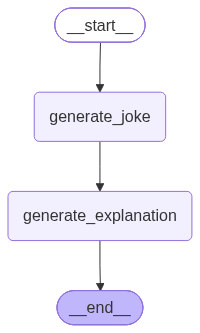

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [19]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza start a band?  \n\nBecause it already had the perfect *crust* of rhythm!',
 'explanation': '**Why the joke works**\n\n| Element | What it is | How it plays in the joke |\n|---------|------------|--------------------------|\n| **The set‑up** | “Why did the pizza start a band?” | The question sets up a classic *why‑does‑it‑do‑this?* joke that invites a punchline that will twist the expectation. |\n| **The punchline** | “Because it already had the perfect *crust* of rhythm!” | The humor comes from a pun that mixes two very different worlds—food and music—into a single phrase. |\n| **Wordplay** | *Crust* | 1. **Pizza crust** – the literal, edible part of a pizza. 2. **Crust (as a base)** – a metaphorical “foundation” or “base” of something (here, a band). |\n| **Rhythm** | A fundamental element of music that gives a piece its beat and groove. | The joke imagines a pizza’s crust providing that essential “base” for rhythm, just as a band needs a

In [21]:
workflow.get_state(config1)
# This returns the latest state of the workflow.

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?  \n\nBecause it already had the perfect *crust* of rhythm!', 'explanation': '**Why the joke works**\n\n| Element | What it is | How it plays in the joke |\n|---------|------------|--------------------------|\n| **The set‑up** | “Why did the pizza start a band?” | The question sets up a classic *why‑does‑it‑do‑this?* joke that invites a punchline that will twist the expectation. |\n| **The punchline** | “Because it already had the perfect *crust* of rhythm!” | The humor comes from a pun that mixes two very different worlds—food and music—into a single phrase. |\n| **Wordplay** | *Crust* | 1. **Pizza crust** – the literal, edible part of a pizza. 2. **Crust (as a base)** – a metaphorical “foundation” or “base” of something (here, a band). |\n| **Rhythm** | A fundamental element of music that gives a piece its beat and groove. | The joke imagines a pizza’s crust providing that essential “base” for rhythm, jus

In [23]:
list(workflow.get_state_history(config1))  # The graph has 4 checkpointer : one before start, one before generate joke,
# one before generate explanation and one before end

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?  \n\nBecause it already had the perfect *crust* of rhythm!', 'explanation': '**Why the joke works**\n\n| Element | What it is | How it plays in the joke |\n|---------|------------|--------------------------|\n| **The set‑up** | “Why did the pizza start a band?” | The question sets up a classic *why‑does‑it‑do‑this?* joke that invites a punchline that will twist the expectation. |\n| **The punchline** | “Because it already had the perfect *crust* of rhythm!” | The humor comes from a pun that mixes two very different worlds—food and music—into a single phrase. |\n| **Wordplay** | *Crust* | 1. **Pizza crust** – the literal, edible part of a pizza. 2. **Crust (as a base)** – a metaphorical “foundation” or “base” of something (here, a band). |\n| **Rhythm** | A fundamental element of music that gives a piece its beat and groove. | The joke imagines a pizza’s crust providing that essential “base” for rhythm, ju

In [24]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti get a promotion?  \nBecause it was always **knot** just a regular noodle!',
 'explanation': '**Why the joke works – a quick “knot”‑analysis**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Setup** | “Why did the spaghetti get a promotion?” | It frames the punchline as a typical work‑place question, so we expect a serious answer (e.g., “because it worked hard”). |\n| **Punchline** | “Because it was always **knot** just a regular noodle!” | The humor is delivered by a homophonic double‑meaning. |\n| **Homophone** | *knot* (a tangle or tie) vs. *not* (the negation). | The word *knot* sounds exactly like *not*, so the reader hears “not” at first, then realizes the joke’s twist is the spelling *knot*. |\n| **Play on spaghetti’s nature** | Spaghetti is a long, thin noodle that can be twisted, curled, and even tied into knots (think of a “knot of spaghetti” in a pot). | By saying the spaghetti is 

In [25]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?  \nBecause it was always **knot** just a regular noodle!', 'explanation': '**Why the joke works – a quick “knot”‑analysis**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Setup** | “Why did the spaghetti get a promotion?” | It frames the punchline as a typical work‑place question, so we expect a serious answer (e.g., “because it worked hard”). |\n| **Punchline** | “Because it was always **knot** just a regular noodle!” | The humor is delivered by a homophonic double‑meaning. |\n| **Homophone** | *knot* (a tangle or tie) vs. *not* (the negation). | The word *knot* sounds exactly like *not*, so the reader hears “not” at first, then realizes the joke’s twist is the spelling *knot*. |\n| **Play on spaghetti’s nature** | Spaghetti is a long, thin noodle that can be twisted, curled, and even tied into knots (think of a “knot of spaghetti” in a pot). | By sayin

In [26]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?  \nBecause it was always **knot** just a regular noodle!', 'explanation': '**Why the joke works – a quick “knot”‑analysis**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Setup** | “Why did the spaghetti get a promotion?” | It frames the punchline as a typical work‑place question, so we expect a serious answer (e.g., “because it worked hard”). |\n| **Punchline** | “Because it was always **knot** just a regular noodle!” | The humor is delivered by a homophonic double‑meaning. |\n| **Homophone** | *knot* (a tangle or tie) vs. *not* (the negation). | The word *knot* sounds exactly like *not*, so the reader hears “not” at first, then realizes the joke’s twist is the spelling *knot*. |\n| **Play on spaghetti’s nature** | Spaghetti is a long, thin noodle that can be twisted, curled, and even tied into knots (think of a “knot of spaghetti” in a pot). | By sayi

# Time Travel

In [ ]:
# In this checkpoint, we just retrieve that point where we have only set topic to pizza in thread 1 and joke has not been
# generated yet
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19a799-7f19-6284-8000-a0dd6129f0da"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f19a799-7f19-6284-8000-a0dd6129f0da'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-17T20:24:05.610748+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19a799-7f16-6251-bfff-e4b83873a126'}}, tasks=(PregelTask(id='dff7780c-ab58-d514-b3c7-0c0c966b473b', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza start a band?  \n\nBecause it already had the perfect *crust* of rhythm!'}),), interrupts=())

In [ ]:
# We restart the workflow from the point where we select topic as pizza and then re run the remaining workflow again
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f19a799-7f19-6284-8000-a0dd6129f0da"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn a **"crust"** of a living! 🍕😄',
 'explanation': '**The joke is a classic word‑play (pun) that mixes literal pizza terms with an idiomatic phrase.**\n\n1. **Literal “crust”**  \n   - A pizza has a *crust*—the outer, doughy edge that holds all the toppings.  \n   - In the joke the pizza is personified and “applies for a job,” which is absurd by itself.  \n\n2. **Idiomatic “cost of living”**  \n   - The common phrase “cost of living” refers to the money one needs to cover everyday expenses.  \n   - The joke replaces **“cost”** with **“crust.”** Because a pizza’s “living” is literally its crust, the phrase becomes “a *crust* of a living.”  \n\n3. **Why it’s funny**  \n   - **Dual meaning:** The punchline hinges on the double meaning of “crust.” It sounds like “cost” (the money you earn) but also literally the part of a pizza that the pizza itself would want to “earn.”  \n   - **Absurd anthropomorph

In [ ]:
# The bottom 4 are from earlier complete run
# The above 3 are from the point where we invoke remaining graph again
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn a **"crust"** of a living! 🍕😄', 'explanation': '**The joke is a classic word‑play (pun) that mixes literal pizza terms with an idiomatic phrase.**\n\n1. **Literal “crust”**  \n   - A pizza has a *crust*—the outer, doughy edge that holds all the toppings.  \n   - In the joke the pizza is personified and “applies for a job,” which is absurd by itself.  \n\n2. **Idiomatic “cost of living”**  \n   - The common phrase “cost of living” refers to the money one needs to cover everyday expenses.  \n   - The joke replaces **“cost”** with **“crust.”** Because a pizza’s “living” is literally its crust, the phrase becomes “a *crust* of a living.”  \n\n3. **Why it’s funny**  \n   - **Dual meaning:** The punchline hinges on the double meaning of “crust.” It sounds like “cost” (the money you earn) but also literally the part of a pizza that the pizza itself would want to “earn.”  \n   - **

# Updating State

In [32]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19a799-7f19-6284-8000-a0dd6129f0da", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19a803-66d6-635b-8001-d75180a46612'}}

In [ ]:
# Notice that we have only updated the state from a checkpoint and not re run the remaining graph again, so 
# last snapshot is of pdation of state only
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19a803-66d6-635b-8001-d75180a46612'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-17T21:11:28.482566+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19a799-7f19-6284-8000-a0dd6129f0da'}}, tasks=(PregelTask(id='ec71245a-2d3e-625d-5cd7-bb149ba5977f', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to earn a **"crust"** of a living! 🍕😄', 'explanation': '**The joke is a classic word‑play (pun) that mixes literal pizza terms with an idiomatic phrase.**\n\n1. **Literal “crust”**  \n   - A pizza has a *crust*—the outer, doughy edge that holds all the toppings.  \n   - In 

In [34]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f19a803-66d6-635b-8001-d75180a46612"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa break up with the pastry?\n\nBecause it was too flaky!',
 'explanation': '**Why the joke works**\n\n1. **Wordplay (puns are the core of many jokes)**  \n   The punchline hinges on the double meaning of the word **“flaky.”**  \n   * *Literal meaning*: Pastries (like croissants, puff pastry, etc.) are famously “flaky” because their layers separate easily when you bite into them.  \n   * *Figurative meaning*: In everyday language, someone who is “flaky” is unreliable, inconsistent, or prone to cancel plans at the last minute.\n\n2. **Setup‑punchline structure**  \n   The question *“Why did the samosa break up with the pastry?”* sets up an expectation that the answer will involve a romantic or culinary twist. The punchline subverts that expectation by giving a single, witty word that satisfies both senses, making the listener realize the joke’s twist.\n\n3. **Cultural mix‑up for extra flavor**  \n   A **samosa** is a deep‑fried, typically sa

In [35]:
# Now we will get remaining workflow too as we have run again after updating topic to samosa
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa break up with the pastry?\n\nBecause it was too flaky!', 'explanation': '**Why the joke works**\n\n1. **Wordplay (puns are the core of many jokes)**  \n   The punchline hinges on the double meaning of the word **“flaky.”**  \n   * *Literal meaning*: Pastries (like croissants, puff pastry, etc.) are famously “flaky” because their layers separate easily when you bite into them.  \n   * *Figurative meaning*: In everyday language, someone who is “flaky” is unreliable, inconsistent, or prone to cancel plans at the last minute.\n\n2. **Setup‑punchline structure**  \n   The question *“Why did the samosa break up with the pastry?”* sets up an expectation that the answer will involve a romantic or culinary twist. The punchline subverts that expectation by giving a single, witty word that satisfies both senses, making the listener realize the joke’s twist.\n\n3. **Cultural mix‑up for extra flavor**  \n   A **samosa** is a deep